In [2]:
import pandas as pd


In [3]:
data=pd.read_csv('/content/Sky_rose_Dataset_Canada.csv')

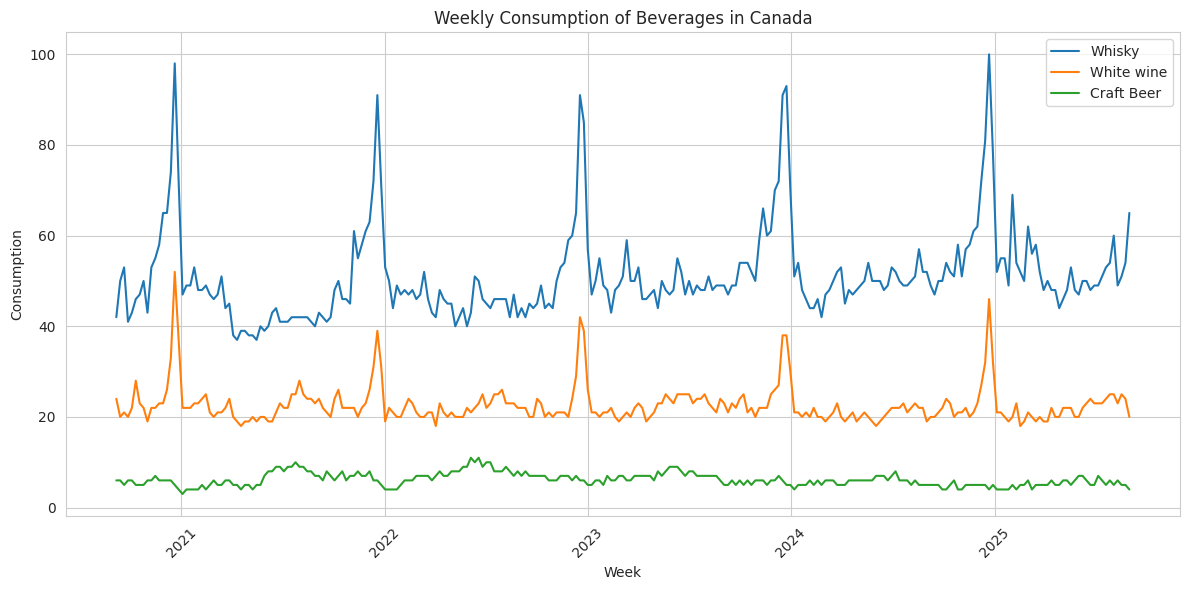

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean the data: drop the first two rows which are not data
# Reset the index to make the multi-level index into columns
data_cleaned = data.reset_index()

# Drop the first two rows which are not data
data_cleaned = data_cleaned.iloc[2:].copy()

# Rename columns for easier access - Assuming the first column is Week and the rest are beverages
# Correct the column selection based on the structure of your data
# If the first column is the index, you might need to reset the index first
# data_cleaned = data_cleaned.reset_index()
data_cleaned.columns = ['Week', 'Whisky', 'White wine', 'Craft Beer']


# Convert 'Week' column to datetime objects
data_cleaned['Week'] = pd.to_datetime(data_cleaned['Week'], format='%Y-%m-%d')

# Convert beverage columns to numeric, coercing errors
data_cleaned['Whisky'] = pd.to_numeric(data_cleaned['Whisky'], errors='coerce')
data_cleaned['White wine'] = pd.to_numeric(data_cleaned['White wine'], errors='coerce')
data_cleaned['Craft Beer'] = pd.to_numeric(data_cleaned['Craft Beer'], errors='coerce')

# Set the style for the plot
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(data_cleaned['Week'], data_cleaned['Whisky'], label='Whisky')
plt.plot(data_cleaned['Week'], data_cleaned['White wine'], label='White wine')
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer'], label='Craft Beer')

# Add title and labels
plt.title('Weekly Consumption of Beverages in Canada')
plt.xlabel('Week')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Calculate 3-week moving average
data_cleaned['Whisky_MA'] = data_cleaned['Whisky'].rolling(window=3).mean()
data_cleaned['White wine_MA'] = data_cleaned['White wine'].rolling(window=3).mean()
data_cleaned['Craft Beer_MA'] = data_cleaned['Craft Beer'].rolling(window=3).mean()

display(data_cleaned)

,Week,Whisky,White wine,Craft Beer,Whisky_MA,White wine_MA,Craft Beer_MA
2,2020-08-30,40,22,7,NaN,NaN,NaN
3,2020-09-06,42,24,6,NaN,NaN,NaN
4,2020-09-13,50,20,6,44.000000,22.000000,6.333333
5,2020-09-20,53,21,5,48.333333,21.666667,5.666667
6,2020-09-27,41,20,6,48.000000,20.333333,5.666667
...,...,...,...,...,...,...,...
259,2025-08-03,60,25,5,55.666667,24.666667,5.333333
260,2025-08-10,49,23,6,54.333333,24.333333,5.666667
261,2025-08-17,51,25,5,53.333333,24.333333,5.333333
262,2025-08-24,54,24,5,51.333333,24.000000,5.333333


In [ ]:
from sklearn.metrics import mean_squared_error

# Drop rows with NaN values in either the original or moving average columns
data_for_error_calculation = data_cleaned.dropna(subset=['Whisky', 'Whisky_MA', 'White wine', 'White wine_MA', 'Craft Beer', 'Craft Beer_MA'])

# Calculate MSE for each beverage
mse_whisky = mean_squared_error(data_for_error_calculation['Whisky'], data_for_error_calculation['Whisky_MA'])
mse_white_wine = mean_squared_error(data_for_error_calculation['White wine'], data_for_error_calculation['White wine_MA'])
mse_craft_beer = mean_squared_error(data_for_error_calculation['Craft Beer'], data_for_error_calculation['Craft Beer_MA'])

# Calculate RMSE for each beverage
rmse_whisky = np.sqrt(mse_whisky)
rmse_white_wine = np.sqrt(mse_white_wine)
rmse_craft_beer = np.sqrt(mse_craft_beer)

# Calculate MAPE for each beverage
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100


mape_whisky = mean_absolute_percentage_error(data_for_error_calculation['Whisky'], data_for_error_calculation['Whisky_MA'])
mape_white_wine = mean_absolute_percentage_error(data_for_error_calculation['White wine'], data_for_error_calculation['White wine_MA'])
mape_craft_beer = mean_absolute_percentage_error(data_for_error_calculation['Craft Beer'], data_for_error_calculation['Craft Beer_MA'])

# Display the results
print("--- Error Metrics (3-Week Moving Average) ---")
print(f"Whisky:")
print(f"  MSE: {mse_whisky:.2f}")
print(f"  RMSE: {rmse_whisky:.2f}")
print(f"  MAPE: {mape_whisky:.2f}%")
print(f"White wine:")
print(f"  MSE: {mse_white_wine:.2f}")
print(f"  RMSE: {rmse_white_wine:.2f}")
print(f"  MAPE: {mape_white_wine:.2f}%")
print(f"Craft Beer:")
print(f"  MSE: {mse_craft_beer:.2f}")
print(f"  RMSE: {rmse_craft_beer:.2f}")
print(f"  MAPE: {mape_craft_beer:.2f}%")

--- Error Metrics (3-Week Moving Average) ---
Whisky:
  MSE: 25.96
  RMSE: 5.10
  MAPE: 5.53%
White wine:
  MSE: 7.08
  RMSE: 2.66
  MAPE: 6.19%
Craft Beer:
  MSE: 0.29
  RMSE: 0.54
  MAPE: 7.30%


In [ ]:
# Calculate 7-week moving average
data_cleaned['Whisky_MA_7'] = data_cleaned['Whisky'].rolling(window=7).mean()
data_cleaned['White wine_MA_7'] = data_cleaned['White wine'].rolling(window=7).mean()
data_cleaned['Craft Beer_MA_7'] = data_cleaned['Craft Beer'].rolling(window=7).mean()
display(data_cleaned)

,Week,Whisky,White wine,Craft Beer,Whisky_MA,White wine_MA,Craft Beer_MA,Whisky_MA_7,White wine_MA_7,Craft Beer_MA_7
2,2020-08-30,40,22,7,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-09-06,42,24,6,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-09-13,50,20,6,44.000000,22.000000,6.333333,NaN,NaN,NaN
5,2020-09-20,53,21,5,48.333333,21.666667,5.666667,NaN,NaN,NaN
6,2020-09-27,41,20,6,48.000000,20.333333,5.666667,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
259,2025-08-03,60,25,5,55.666667,24.666667,5.333333,52.000000,23.857143,5.571429
260,2025-08-10,49,23,6,54.333333,24.333333,5.666667,52.142857,23.714286,5.714286
261,2025-08-17,51,25,5,53.333333,24.333333,5.333333,52.428571,24.000000,5.714286
262,2025-08-24,54,24,5,51.333333,24.000000,5.333333,53.142857,24.142857,5.428571


In [ ]:
from sklearn.metrics import mean_squared_error

# Drop rows with NaN values in either the original or 7-week moving average columns
data_for_error_calculation_7 = data_cleaned.dropna(subset=['Whisky', 'Whisky_MA_7', 'White wine', 'White wine_MA_7', 'Craft Beer', 'Craft Beer_MA_7'])

# Calculate MSE for each beverage (7-week MA)
mse_whisky_7 = mean_squared_error(data_for_error_calculation_7['Whisky'], data_for_error_calculation_7['Whisky_MA_7'])
mse_white_wine_7 = mean_squared_error(data_for_error_calculation_7['White wine'], data_for_error_calculation_7['White wine_MA_7'])
mse_craft_beer_7 = mean_squared_error(data_for_error_calculation_7['Craft Beer'], data_for_error_calculation_7['Craft Beer_MA_7'])

# Calculate RMSE for each beverage (7-week MA)
rmse_whisky_7 = np.sqrt(mse_whisky_7)
rmse_white_wine_7 = np.sqrt(mse_white_wine_7)
rmse_craft_beer_7 = np.sqrt(mse_craft_beer_7)

# Calculate MAPE for each beverage (7-week MA)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_whisky_7 = mean_absolute_percentage_error(data_for_error_calculation_7['Whisky'], data_for_error_calculation_7['Whisky_MA_7'])
mape_white_wine_7 = mean_absolute_percentage_error(data_for_error_calculation_7['White wine'], data_for_error_calculation_7['White wine_MA_7'])
mape_craft_beer_7 = mean_absolute_percentage_error(data_for_error_calculation_7['Craft Beer'], data_for_error_calculation_7['Craft Beer_MA_7'])

# Display the results
print("--- Error Metrics (7-Week Moving Average) ---")
print(f"Whisky:")
print(f"  MSE: {mse_whisky_7:.2f}")
print(f"  RMSE: {rmse_whisky_7:.2f}")
print(f"  MAPE: {mape_whisky_7:.2f}%")
print(f"White wine:")
print(f"  MSE: {mse_white_wine_7:.2f}")
print(f"  RMSE: {rmse_white_wine_7:.2f}")
print(f"  MAPE: {mape_white_wine_7:.2f}%")
print(f"Craft Beer:")
print(f"  MSE: {mse_craft_beer_7:.2f}")
print(f"  RMSE: {rmse_craft_beer_7:.2f}")
print(f"  MAPE: {mape_craft_beer_7:.2f}%")

--- Error Metrics (7-Week Moving Average) ---
Whisky:
  MSE: 58.96
  RMSE: 7.68
  MAPE: 8.74%
White wine:
  MSE: 14.93
  RMSE: 3.86
  MAPE: 9.47%
Craft Beer:
  MSE: 0.68
  RMSE: 0.82
  MAPE: 11.06%


In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Apply Simple Exponential Smoothing (SES)
# We'll use a smoothing level alpha, which can be tuned. A common starting point is 0.2.
alpha = 0.2

data_cleaned['Whisky_SES'] = SimpleExpSmoothing(data_cleaned['Whisky']).fit(smoothing_level=alpha).fittedvalues
data_cleaned['White wine_SES'] = SimpleExpSmoothing(data_cleaned['White wine']).fit(smoothing_level=alpha).fittedvalues
data_cleaned['Craft Beer_SES'] = SimpleExpSmoothing(data_cleaned['Craft Beer']).fit(smoothing_level=alpha).fittedvalues

display(data_cleaned)

/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


,Week,Whisky,White wine,Craft Beer,Whisky_MA,White wine_MA,Craft Beer_MA,Whisky_MA_7,White wine_MA_7,Craft Beer_MA_7,Whisky_SES,White wine_SES,Craft Beer_SES
2,2020-08-30,40,22,7,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,22.000000,7.000000
3,2020-09-06,42,24,6,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,22.000000,7.000000
4,2020-09-13,50,20,6,44.000000,22.000000,6.333333,NaN,NaN,NaN,40.400000,22.400000,6.800000
5,2020-09-20,53,21,5,48.333333,21.666667,5.666667,NaN,NaN,NaN,42.320000,21.920000,6.640000
6,2020-09-27,41,20,6,48.000000,20.333333,5.666667,NaN,NaN,NaN,44.456000,21.736000,6.312000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,2025-08-03,60,25,5,55.666667,24.666667,5.333333,52.000000,23.857143,5.571429,50.925788,23.198744,5.797577
260,2025-08-10,49,23,6,54.333333,24.333333,5.666667,52.142857,23.714286,5.714286,52.740630,23.558995,5.638061
261,2025-08-17,51,25,5,53.333333,24.333333,5.333333,52.428571,24.000000,5.714286,51.992504,23.447196,5.710449
262,2025-08-24,54,24,5,51.333333,24.000000,5.333333,53.142857,24.142857,5.428571,51.794003,23.757757,5.568359


In [ ]:
from sklearn.metrics import mean_squared_error

# Drop rows with NaN values in either the original or SES columns
data_for_error_calculation_ses = data_cleaned.dropna(subset=['Whisky', 'Whisky_SES', 'White wine', 'White wine_SES', 'Craft Beer', 'Craft Beer_SES'])

# Calculate MSE for each beverage (SES)
mse_whisky_ses = mean_squared_error(data_for_error_calculation_ses['Whisky'], data_for_error_calculation_ses['Whisky_SES'])
mse_white_wine_ses = mean_squared_error(data_for_error_calculation_ses['White wine'], data_for_error_calculation_ses['White wine_SES'])
mse_craft_beer_ses = mean_squared_error(data_for_error_calculation_ses['Craft Beer'], data_for_error_calculation_ses['Craft Beer_SES'])

# Calculate RMSE for each beverage (SES)
rmse_whisky_ses = np.sqrt(mse_whisky_ses)
rmse_white_wine_ses = np.sqrt(mse_white_wine_ses)
rmse_craft_beer_ses = np.sqrt(mse_craft_beer_ses)

# Calculate MAPE for each beverage (SES)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_whisky_ses = mean_absolute_percentage_error(data_for_error_calculation_ses['Whisky'], data_for_error_calculation_ses['Whisky_SES'])
mape_white_wine_ses = mean_absolute_percentage_error(data_for_error_calculation_ses['White wine'], data_for_error_calculation_ses['White wine_SES'])
mape_craft_beer_ses = mean_absolute_percentage_error(data_for_error_calculation_ses['Craft Beer'], data_for_error_calculation_ses['Craft Beer_SES'])

# Display the results
print("--- Error Metrics (Simple Exponential Smoothing) ---")
print(f"Whisky:")
print(f"  MSE: {mse_whisky_ses:.2f}")
print(f"  RMSE: {rmse_whisky_ses:.2f}")
print(f"  MAPE: {mape_whisky_ses:.2f}%")
print(f"White wine:")
print(f"  MSE: {mse_white_wine_ses:.2f}")
print(f"  RMSE: {rmse_white_wine_ses:.2f}")
print(f"  MAPE: {mape_white_wine_ses:.2f}%")
print(f"Craft Beer:")
print(f"  MSE: {mse_craft_beer_ses:.2f}")
print(f"  RMSE: {rmse_craft_beer_ses:.2f}")
print(f"  MAPE: {mape_craft_beer_ses:.2f}%")

--- Error Metrics (Simple Exponential Smoothing) ---
Whisky:
  MSE: 72.23
  RMSE: 8.50
  MAPE: 10.01%
White wine:
  MSE: 16.58
  RMSE: 4.07
  MAPE: 10.21%
Craft Beer:
  MSE: 0.92
  RMSE: 0.96
  MAPE: 12.95%


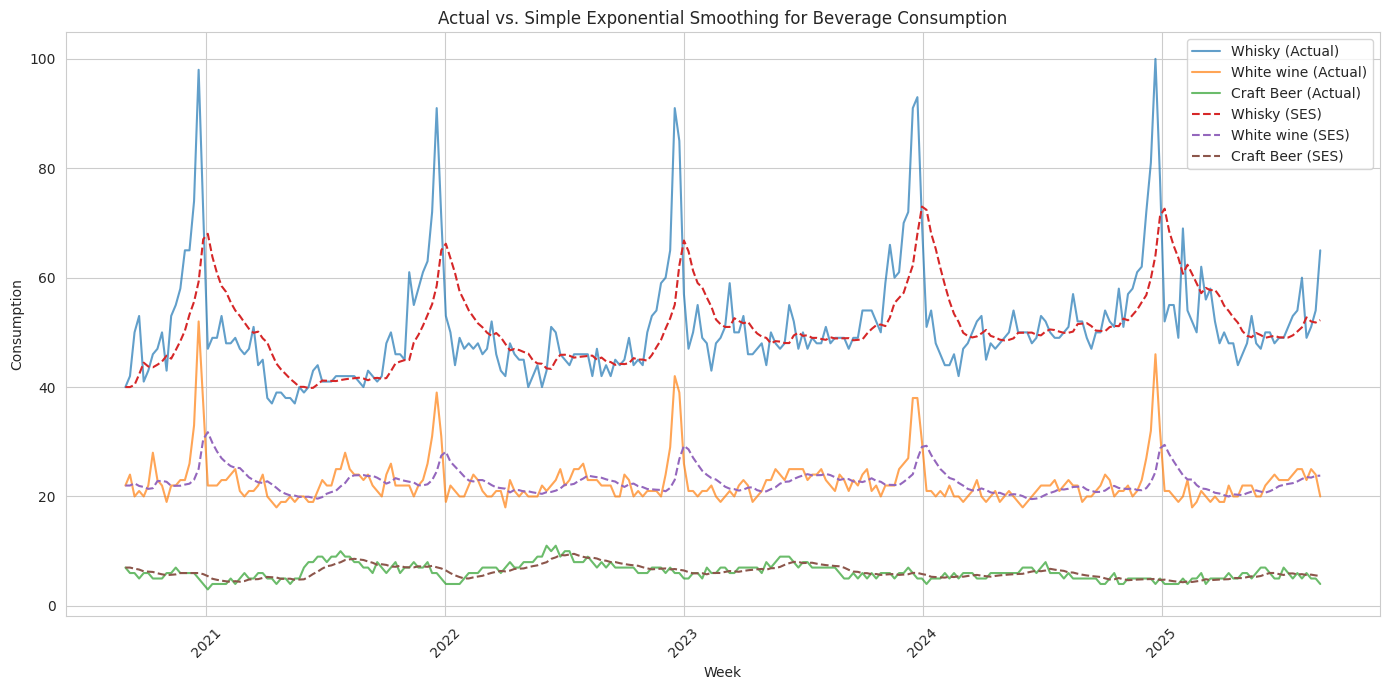

In [ ]:
# Set the style for the plot
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(data_cleaned['Week'], data_cleaned['Whisky'], label='Whisky (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['White wine'], label='White wine (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer'], label='Craft Beer (Actual)', alpha=0.7)

# Plot SES values
plt.plot(data_cleaned['Week'], data_cleaned['Whisky_SES'], label='Whisky (SES)', linestyle='--')
plt.plot(data_cleaned['Week'], data_cleaned['White wine_SES'], label='White wine (SES)', linestyle='--')
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer_SES'], label='Craft Beer (SES)', linestyle='--')


# Add title and labels
plt.title('Actual vs. Simple Exponential Smoothing for Beverage Consumption')
plt.xlabel('Week')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Apply Double Exponential Smoothing (DES)
# We'll use smoothing levels alpha and beta, which can be tuned.
alpha = 0.2  # Smoothing level for the level
beta = 0.1   # Smoothing level for the trend

data_cleaned['Whisky_DES'] = ExponentialSmoothing(data_cleaned['Whisky'], trend='add').fit(smoothing_level=alpha, smoothing_trend=beta).fittedvalues
data_cleaned['White wine_DES'] = ExponentialSmoothing(data_cleaned['White wine'], trend='add').fit(smoothing_level=alpha, smoothing_trend=beta).fittedvalues
data_cleaned['Craft Beer_DES'] = ExponentialSmoothing(data_cleaned['Craft Beer'], trend='add').fit(smoothing_level=alpha, smoothing_trend=beta).fittedvalues

display(data_cleaned)

,Week,Whisky,White wine,Craft Beer,Whisky_MA,White wine_MA,Craft Beer_MA,Whisky_MA_7,White wine_MA_7,Craft Beer_MA_7,Whisky_SES,White wine_SES,Craft Beer_SES,Whisky_DES,White wine_DES,Craft Beer_DES
2,2020-08-30,40,22,7,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,22.000000,7.000000,45.266614,21.946557,6.126294
3,2020-09-06,42,24,6,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,22.000000,7.000000,44.994219,22.218207,6.242832
4,2020-09-13,50,20,6,44.000000,22.000000,6.333333,NaN,NaN,NaN,40.400000,22.400000,6.800000,45.116419,22.871163,6.131206
5,2020-09-20,53,21,5,48.333333,21.666667,5.666667,NaN,NaN,NaN,42.320000,21.920000,6.640000,46.911850,22.536105,6.039281
6,2020-09-27,41,20,6,48.000000,20.333333,5.666667,NaN,NaN,NaN,44.456000,21.736000,6.312000,49.069958,22.437336,5.744956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,2025-08-03,60,25,5,55.666667,24.666667,5.333333,52.000000,23.857143,5.571429,50.925788,23.198744,5.797577,49.105625,23.588050,6.100598
260,2025-08-10,49,23,6,54.333333,24.333333,5.666667,52.142857,23.714286,5.714286,52.740630,23.558995,5.638061,51.451416,24.098425,5.899563
261,2025-08-17,51,25,5,53.333333,24.333333,5.333333,52.428571,24.000000,5.714286,51.992504,23.447196,5.710449,51.079020,24.084757,5.940743
262,2025-08-24,54,24,5,51.333333,24.000000,5.333333,53.142857,24.142857,5.428571,51.794003,23.757757,5.568359,51.179523,24.492127,5.754873


In [ ]:

from sklearn.metrics import mean_squared_error

# Drop rows with NaN values in either the original or DES columns
data_for_error_calculation_des = data_cleaned.dropna(subset=['Whisky', 'Whisky_DES', 'White wine', 'White wine_DES', 'Craft Beer', 'Craft Beer_DES'])

# Calculate MSE for each beverage (DES)
mse_whisky_des = mean_squared_error(data_for_error_calculation_des['Whisky'], data_for_error_calculation_des['Whisky_DES'])
mse_white_wine_des = mean_squared_error(data_for_error_calculation_des['White wine'], data_for_error_calculation_des['White wine_DES'])
mse_craft_beer_des = mean_squared_error(data_for_error_calculation_des['Craft Beer'], data_for_error_calculation_des['Craft Beer_DES'])

# Calculate RMSE for each beverage (DES)
rmse_whisky_des = np.sqrt(mse_whisky_des)
rmse_white_wine_des = np.sqrt(mse_white_wine_des)
rmse_craft_beer_des = np.sqrt(mse_craft_beer_des)

# Calculate MAPE for each beverage (DES)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_whisky_des = mean_absolute_percentage_error(data_for_error_calculation_des['Whisky'], data_for_error_calculation_des['Whisky_DES'])
mape_white_wine_des = mean_absolute_percentage_error(data_for_error_calculation_des['White wine'], data_for_error_calculation_des['White wine_DES'])
mape_craft_beer_des = mean_absolute_percentage_error(data_for_error_calculation_des['Craft Beer'], data_for_error_calculation_des['Craft Beer_DES'])

# Display the results
print("--- Error Metrics (Double Exponential Smoothing) ---")
print(f"Whisky:")
print(f"  MSE: {mse_whisky_des:.2f}")
print(f"  RMSE: {rmse_whisky_des:.2f}")
print(f"  MAPE: {mape_whisky_des:.2f}%")
print(f"White wine:")
print(f"  MSE: {mse_white_wine_des:.2f}")
print(f"  RMSE: {rmse_white_wine_des:.2f}")
print(f"  MAPE: {mape_white_wine_des:.2f}%")
print(f"Craft Beer:")
print(f"  MSE: {mse_craft_beer_des:.2f}")
print(f"  RMSE: {rmse_craft_beer_des:.2f}")
print(f"  MAPE: {mape_craft_beer_des:.2f}%")

--- Error Metrics (Double Exponential Smoothing) ---
Whisky:
  MSE: 84.65
  RMSE: 9.20
  MAPE: 11.63%
White wine:
  MSE: 19.07
  RMSE: 4.37
  MAPE: 11.66%
Craft Beer:
  MSE: 1.06
  RMSE: 1.03
  MAPE: 13.82%


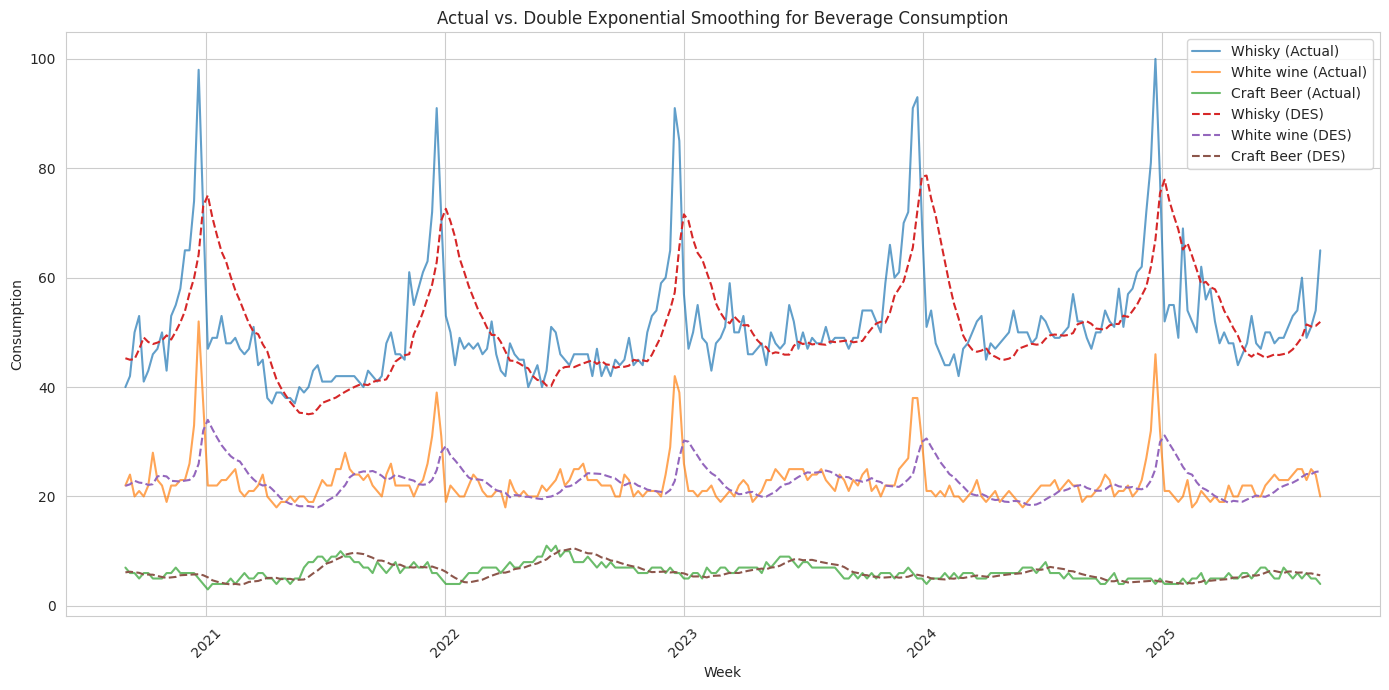

In [ ]:
# Set the style for the plot
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(data_cleaned['Week'], data_cleaned['Whisky'], label='Whisky (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['White wine'], label='White wine (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer'], label='Craft Beer (Actual)', alpha=0.7)

# Plot DES values
plt.plot(data_cleaned['Week'], data_cleaned['Whisky_DES'], label='Whisky (DES)', linestyle='--')
plt.plot(data_cleaned['Week'], data_cleaned['White wine_DES'], label='White wine (DES)', linestyle='--')
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer_DES'], label='Craft Beer (DES)', linestyle='--')


# Add title and labels
plt.title('Actual vs. Double Exponential Smoothing for Beverage Consumption')
plt.xlabel('Week')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Apply Triple Exponential Smoothing (TES)
# This method accounts for level, trend, and seasonality.
# We'll use smoothing levels alpha, beta, and gamma, and a seasonal period.
alpha = 0.2  # Smoothing level for the level
beta = 0.1   # Smoothing level for the trend
gamma = 0.2  # Smoothing level for the seasonality
seasonal_period = 52 # Assuming yearly seasonality in weekly data

data_cleaned['Whisky_TES'] = ExponentialSmoothing(
    data_cleaned['Whisky'],
    trend='add',
    seasonal='add', # Assuming additive seasonality
    seasonal_periods=seasonal_period
).fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma).fittedvalues

data_cleaned['White wine_TES'] = ExponentialSmoothing(
    data_cleaned['White wine'],
    trend='add',
    seasonal='add',
    seasonal_periods=seasonal_period
).fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma).fittedvalues

data_cleaned['Craft Beer_TES'] = ExponentialSmoothing(
    data_cleaned['Craft Beer'],
    trend='add',
    seasonal='add',
    seasonal_periods=seasonal_period
).fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma).fittedvalues

display(data_cleaned)

,Week,Whisky,White wine,Craft Beer,Whisky_MA,White wine_MA,Craft Beer_MA,Whisky_MA_7,White wine_MA_7,Craft Beer_MA_7,Whisky_SES,White wine_SES,Craft Beer_SES,Whisky_DES,White wine_DES,Craft Beer_DES,Whisky_TES,White wine_TES,Craft Beer_TES
2,2020-08-30,40,22,7,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,22.000000,7.000000,45.266614,21.946557,6.126294,42.827507,22.480473,6.608734
3,2020-09-06,42,24,6,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,22.000000,7.000000,44.994219,22.218207,6.242832,44.445283,22.271905,6.008741
4,2020-09-13,50,20,6,44.000000,22.000000,6.333333,NaN,NaN,NaN,40.400000,22.400000,6.800000,45.116419,22.871163,6.131206,43.286512,21.494913,5.964507
5,2020-09-20,53,21,5,48.333333,21.666667,5.666667,NaN,NaN,NaN,42.320000,21.920000,6.640000,46.911850,22.536105,6.039281,46.260036,21.234285,6.082667
6,2020-09-27,41,20,6,48.000000,20.333333,5.666667,NaN,NaN,NaN,44.456000,21.736000,6.312000,49.069958,22.437336,5.744956,45.242882,20.666720,5.695053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,2025-08-03,60,25,5,55.666667,24.666667,5.333333,52.000000,23.857143,5.571429,50.925788,23.198744,5.797577,49.105625,23.588050,6.100598,52.097571,23.842620,5.279988
260,2025-08-10,49,23,6,54.333333,24.333333,5.666667,52.142857,23.714286,5.714286,52.740630,23.558995,5.638061,51.451416,24.098425,5.899563,52.008849,23.874137,5.127049
261,2025-08-17,51,25,5,53.333333,24.333333,5.333333,52.428571,24.000000,5.714286,51.992504,23.447196,5.710449,51.079020,24.084757,5.940743,54.398614,23.339087,4.704498
262,2025-08-24,54,24,5,51.333333,24.000000,5.333333,53.142857,24.142857,5.428571,51.794003,23.757757,5.568359,51.179523,24.492127,5.754873,50.459700,23.878484,4.596897


In [ ]:
from sklearn.metrics import mean_squared_error

# Drop rows with NaN values in either the original or TES columns
data_for_error_calculation_tes = data_cleaned.dropna(subset=['Whisky', 'Whisky_TES', 'White wine', 'White wine_TES', 'Craft Beer', 'Craft Beer_TES'])

# Calculate MSE for each beverage (TES)
mse_whisky_tes = mean_squared_error(data_for_error_calculation_tes['Whisky'], data_for_error_calculation_tes['Whisky_TES'])
mse_white_wine_tes = mean_squared_error(data_for_error_calculation_tes['White wine'], data_for_error_calculation_tes['White wine_TES'])
mse_craft_beer_tes = mean_squared_error(data_for_error_calculation_tes['Craft Beer'], data_for_error_calculation_tes['Craft Beer_TES'])

# Calculate RMSE for each beverage (TES)
rmse_whisky_tes = np.sqrt(mse_whisky_tes)
rmse_white_wine_tes = np.sqrt(mse_white_wine_tes)
rmse_craft_beer_tes = np.sqrt(mse_craft_beer_tes)

# Calculate MAPE for each beverage (TES)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_whisky_tes = mean_absolute_percentage_error(data_for_error_calculation_tes['Whisky'], data_for_error_calculation_tes['Whisky_TES'])
mape_white_wine_tes = mean_absolute_percentage_error(data_for_error_calculation_tes['White wine'], data_for_error_calculation_tes['White wine_TES'])
mape_craft_beer_tes = mean_absolute_percentage_error(data_for_error_calculation_tes['Craft Beer'], data_for_error_calculation_tes['Craft Beer_TES'])

# Display the results
print("--- Error Metrics (Triple Exponential Smoothing) ---")
print(f"Whisky:")
print(f"  MSE: {mse_whisky_tes:.2f}")
print(f"  RMSE: {rmse_whisky_tes:.2f}")
print(f"  MAPE: {mape_whisky_tes:.2f}%")
print(f"White wine:")
print(f"  MSE: {mse_white_wine_tes:.2f}")
print(f"  RMSE: {rmse_white_wine_tes:.2f}")
print(f"  MAPE: {mape_white_wine_tes:.2f}%")
print(f"Craft Beer:")
print(f"  MSE: {mse_craft_beer_tes:.2f}")
print(f"  RMSE: {rmse_craft_beer_tes:.2f}")
print(f"  MAPE: {mape_craft_beer_tes:.2f}%")

--- Error Metrics (Triple Exponential Smoothing) ---
Whisky:
  MSE: 17.01
  RMSE: 4.12
  MAPE: 5.37%
White wine:
  MSE: 3.96
  RMSE: 1.99
  MAPE: 5.59%
Craft Beer:
  MSE: 0.49
  RMSE: 0.70
  MAPE: 9.31%


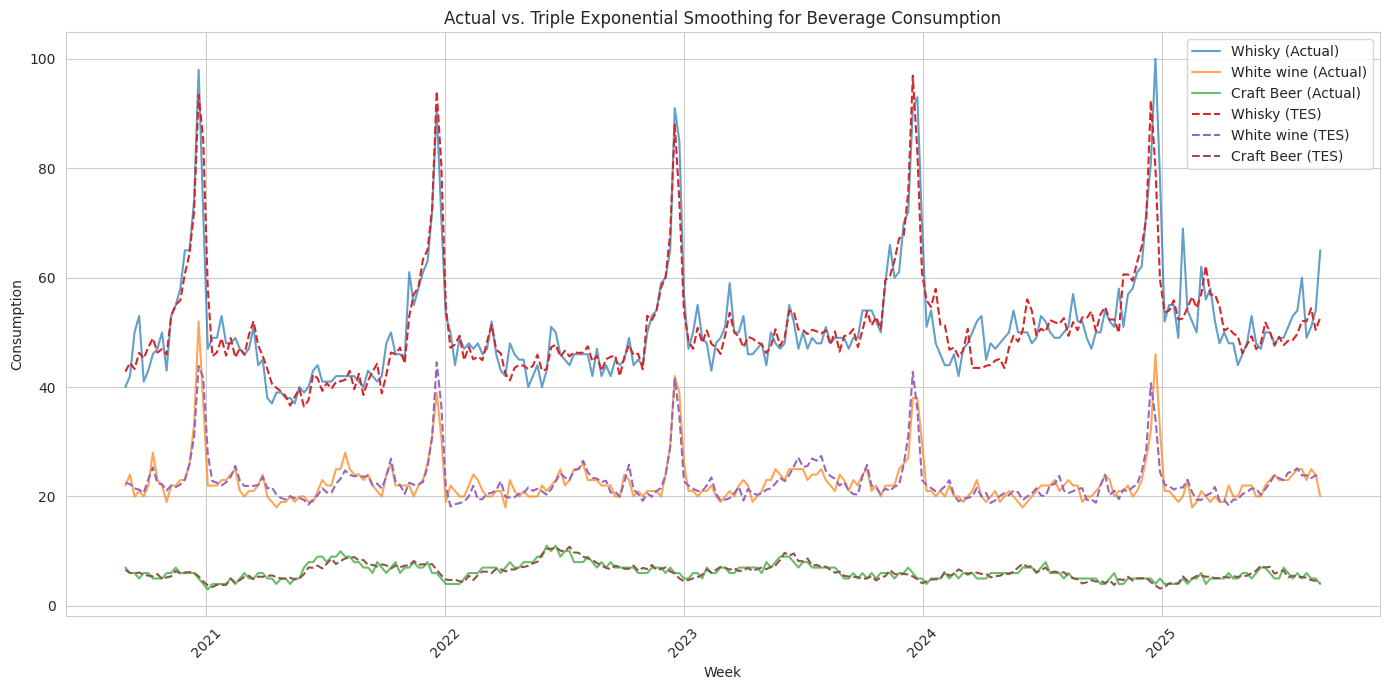

In [ ]:
# Set the style for the plot
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(data_cleaned['Week'], data_cleaned['Whisky'], label='Whisky (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['White wine'], label='White wine (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer'], label='Craft Beer (Actual)', alpha=0.7)

# Plot TES values
plt.plot(data_cleaned['Week'], data_cleaned['Whisky_TES'], label='Whisky (TES)', linestyle='--')
plt.plot(data_cleaned['Week'], data_cleaned['White wine_TES'], label='White wine (TES)', linestyle='--')
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer_TES'], label='Craft Beer (TES)', linestyle='--')


# Add title and labels
plt.title('Actual vs. Triple Exponential Smoothing for Beverage Consumption')
plt.xlabel('Week')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on each beverage
adf_whisky = adfuller(data_cleaned['Whisky'].dropna())
adf_white_wine = adfuller(data_cleaned['White wine'].dropna())
adf_craft_beer = adfuller(data_cleaned['Craft Beer'].dropna())

# Print the results
print("--- ADF Test Results ---")
print("Whisky:")
print(f"  ADF Statistic: {adf_whisky[0]:.2f}")
print(f"  P-value: {adf_whisky[1]:.3f}")
print("  Critical Values:")
for key, value in adf_whisky[4].items():
    print(f"    {key}: {value:.2f}")

print("\nWhite wine:")
print(f"  ADF Statistic: {adf_white_wine[0]:.2f}")
print(f"  P-value: {adf_white_wine[1]:.3f}")
print("  Critical Values:")
for key, value in adf_white_wine[4].items():
    print(f"    {key}: {value:.2f}")

print("\nCraft Beer:")
print(f"  ADF Statistic: {adf_craft_beer[0]:.2f}")
print(f"  P-value: {adf_craft_beer[1]:.3f}")
print("  Critical Values:")
for key, value in adf_craft_beer[4].items():
    print(f"    {key}: {value:.2f}")

--- ADF Test Results ---
Whisky:
  ADF Statistic: -5.06
  P-value: 0.000
  Critical Values:
    1%: -3.46
    5%: -2.87
    10%: -2.57

White wine:
  ADF Statistic: -6.96
  P-value: 0.000
  Critical Values:
    1%: -3.46
    5%: -2.87
    10%: -2.57

Craft Beer:
  ADF Statistic: -3.39
  P-value: 0.011
  Critical Values:
    1%: -3.46
    5%: -2.87
    10%: -2.57


H0=the data is non-stationary ;  H1= the data is stationary. P-Value < 0.05, hence Accept H1. Data is stationary.


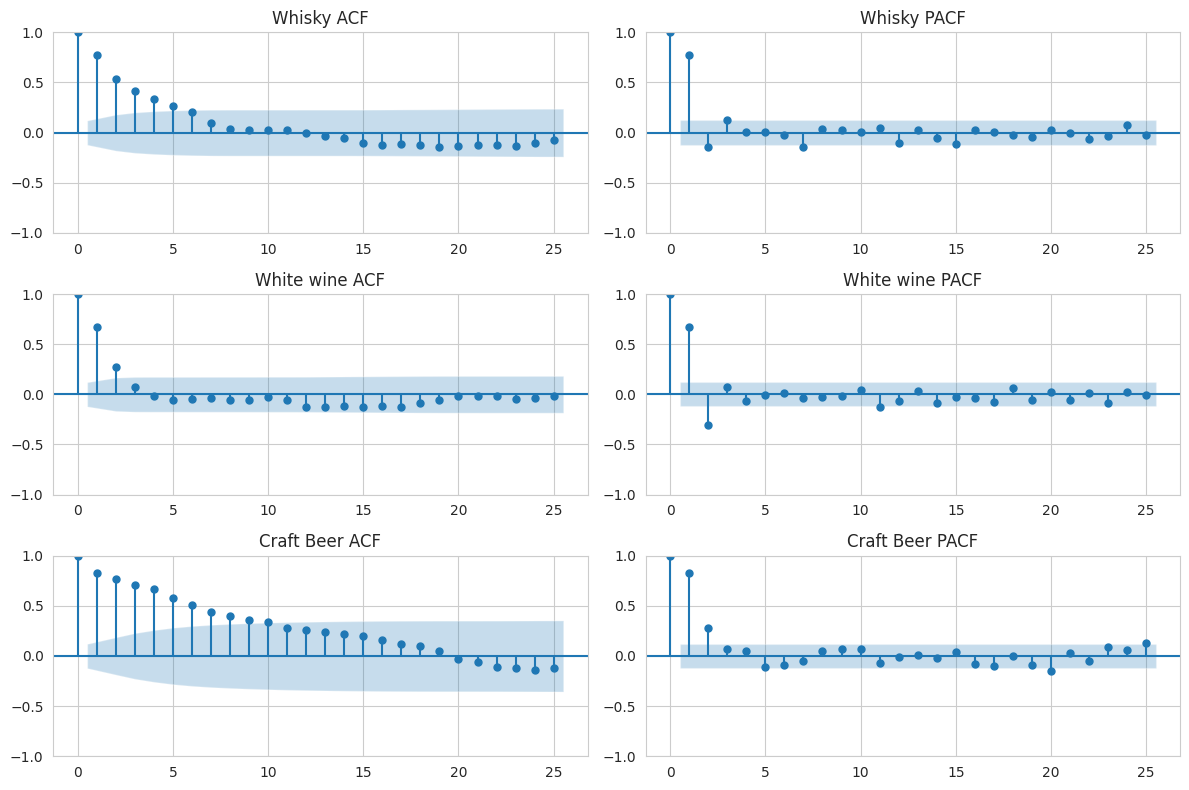

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create ACF and PACF plots for each beverage
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

plot_acf(data_cleaned['Whisky'].dropna(), ax=axes[0, 0], title='Whisky ACF')
plot_pacf(data_cleaned['Whisky'].dropna(), ax=axes[0, 1], title='Whisky PACF')

plot_acf(data_cleaned['White wine'].dropna(), ax=axes[1, 0], title='White wine ACF')
plot_pacf(data_cleaned['White wine'].dropna(), ax=axes[1, 1], title='White wine PACF')

plot_acf(data_cleaned['Craft Beer'].dropna(), ax=axes[2, 0], title='Craft Beer ACF')
plot_pacf(data_cleaned['Craft Beer'].dropna(), ax=axes[2, 1], title='Craft Beer PACF')

plt.tight_layout()
plt.show()

PACF(p): Whisky-1,2,3,6 ; White wine-1,2,11 ; Craft Beer-1,2,5 // ACF(q): Whisky-1,2,3,4,5 ; White wine-1,2 ; Craft Beer-1,2,3,4,5

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA order (p, d, q)
order = (1, 0, 1)

# Fit ARIMA model for Whisky
model_whisky = ARIMA(data_cleaned['Whisky'].dropna(), order=order)
results_whisky = model_whisky.fit()
print("--- ARIMA (1,0,1) Results for Whisky ---")
print(results_whisky.summary())

# Fit ARIMA model for White wine
model_white_wine = ARIMA(data_cleaned['White wine'].dropna(), order=order)
results_white_wine = model_white_wine.fit()
print("\n--- ARIMA (1,0,1) Results for White wine ---")
print(results_white_wine.summary())

# Fit ARIMA model for Craft Beer
model_craft_beer = ARIMA(data_cleaned['Craft Beer'].dropna(), order=order)
results_craft_beer = model_craft_beer.fit()
print("\n--- ARIMA (1,0,1) Results for Craft Beer ---")
print(results_craft_beer.summary())

--- ARIMA (1,0,1) Results for Whisky ---
                               SARIMAX Results                                
Dep. Variable:                 Whisky   No. Observations:                  262
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -853.081
Date:                Fri, 05 Sep 2025   AIC                           1714.163
Time:                        10:32:55   BIC                           1728.436
Sample:                             0   HQIC                          1719.900
                                - 262                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.1020      2.206     23.162      0.000      46.778      55.426
ar.L1          0.6788      0.039     17.580      0.000       0.603       0.754
ma.L1      

In [8]:
!pip uninstall numpy -y
!pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 46.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
!pip install pmdarima

  Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.3 MB)


In [5]:
from pmdarima import auto_arima

# Perform Auto-ARIMA for Whisky
print("--- Auto-ARIMA Results for Whisky ---")
auto_arima_whisky = auto_arima(data_cleaned['Whisky'].dropna(), seasonal=True, m=52, stepwise=True, suppress_warnings=True, error_action='ignore', trace=True)
print(auto_arima_whisky.summary())

# Perform Auto-ARIMA for White wine
print("\n--- Auto-ARIMA Results for White wine ---")
auto_arima_white_wine = auto_arima(data_cleaned['White wine'].dropna(), seasonal=True, m=52, stepwise=True, suppress_warnings=True, error_action='ignore', trace=True)
print(auto_arima_white_wine.summary())

# Perform Auto-ARIMA for Craft Beer
print("\n--- Auto-ARIMA Results for Craft Beer ---")
auto_arima_craft_beer = auto_arima(data_cleaned['Craft Beer'].dropna(), seasonal=True, m=52, stepwise=True, suppress_warnings=True, error_action='ignore', trace=True)
print(auto_arima_craft_beer.summary())

--- Auto-ARIMA Results for Whisky ---
Performing stepwise search to minimize aic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=inf, Time=15.71 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=1952.280, Time=0.02 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=inf, Time=5.86 sec


...

 ARIMA(0,1,2)(2,0,0)[52]             : AIC=595.184, Time=5.52 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(2,0,0)[52]             : AIC=inf, Time=6.58 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(2,0,0)[52]             : AIC=597.052, Time=19.56 sec

Best model:  ARIMA(0,1,1)(2,0,0)[52]          
Total fit time: 249.664 seconds
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  261
Model:             SARIMAX(0, 1, 1)x(2, 0, [], 52)   Log Likelihood                -292.609
Date:                             Fri, 05 Sep 2025   AIC                            593.218
Time:                                     16:09:28   BIC                            607.461
Sample:                                          0   HQIC                           598.944
                                             - 261                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA order (p, d, q)
order = (1, 0, 2)

# Fit ARIMA model for Whisky
model_whisky = ARIMA(data_cleaned['Whisky'].dropna(), order=order)
results_whisky = model_whisky.fit()
print("--- ARIMA (1,0,2) Results for Whisky ---")
print(results_whisky.summary())

# Fit ARIMA model for White wine
model_white_wine = ARIMA(data_cleaned['White wine'].dropna(), order=order)
results_white_wine = model_white_wine.fit()
print("\n--- ARIMA (1,0,2) Results for White wine ---")
print(results_white_wine.summary())

# Fit ARIMA model for Craft Beer
model_craft_beer = ARIMA(data_cleaned['Craft Beer'].dropna(), order=order)
results_craft_beer = model_craft_beer.fit()
print("\n--- ARIMA (1,0,2) Results for Craft Beer ---")
print(results_craft_beer.summary())

--- ARIMA (1,0,2) Results for Whisky ---
                               SARIMAX Results                                
Dep. Variable:                 Whisky   No. Observations:                  261
Model:                 ARIMA(1, 0, 2)   Log Likelihood                -849.459
Date:                Fri, 05 Sep 2025   AIC                           1708.918
Time:                        14:35:18   BIC                           1726.741
Sample:                             0   HQIC                          1716.083
                                - 261                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.1604      2.471     20.707      0.000      46.318      56.003
ar.L1          0.7589      0.082      9.254      0.000       0.598       0.920
ma.L1      

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA order (p, d, q)
order = (2, 0, 1)

# Fit ARIMA model for Whisky
model_whisky = ARIMA(data_cleaned['Whisky'].dropna(), order=order)
results_whisky = model_whisky.fit()
print("--- ARIMA (1,0,3) Results for Whisky ---")
print(results_whisky.summary())

# Fit ARIMA model for White wine
model_white_wine = ARIMA(data_cleaned['White wine'].dropna(), order=order)
results_white_wine = model_white_wine.fit()
print("\n--- ARIMA (1,0,3) Results for White wine ---")
print(results_white_wine.summary())

# Fit ARIMA model for Craft Beer
model_craft_beer = ARIMA(data_cleaned['Craft Beer'].dropna(), order=order)
results_craft_beer = model_craft_beer.fit()
print("\n--- ARIMA (1,0,3) Results for Craft Beer ---")
print(results_craft_beer.summary())

--- ARIMA (1,0,3) Results for Whisky ---
                               SARIMAX Results                                
Dep. Variable:                 Whisky   No. Observations:                  261
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -849.764
Date:                Fri, 05 Sep 2025   AIC                           1709.528
Time:                        14:37:55   BIC                           1727.350
Sample:                             0   HQIC                          1716.692
                                - 261                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.1557      2.332     21.936      0.000      46.585      55.726
ar.L1          0.4678      0.289      1.616      0.106      -0.099       1.035
ar.L2      

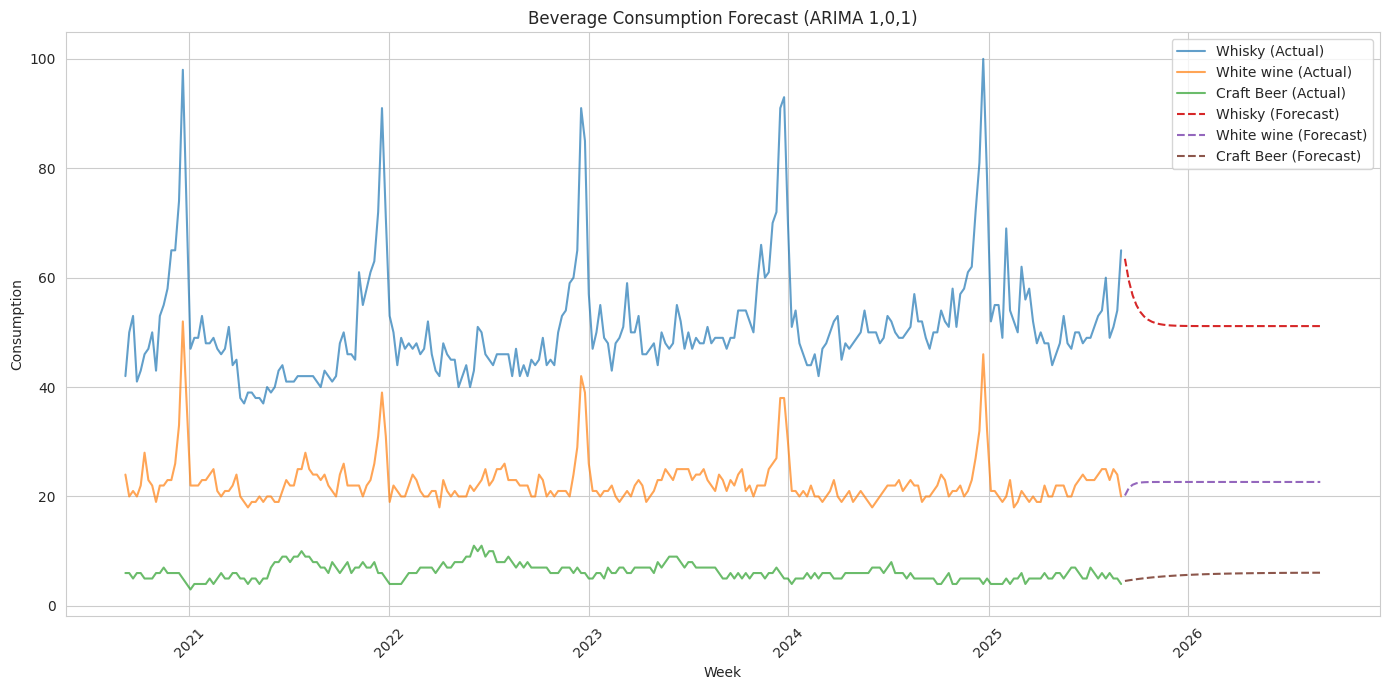

In [6]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define the ARIMA order (p, d, q)
order = (1, 0, 1)

# Fit ARIMA model for Whisky
model_whisky = ARIMA(data_cleaned['Whisky'].dropna(), order=order)
results_whisky = model_whisky.fit()

# Fit ARIMA model for White wine
model_white_wine = ARIMA(data_cleaned['White wine'].dropna(), order=order)
results_white_wine = model_white_wine.fit()

# Fit ARIMA model for Craft Beer
model_craft_beer = ARIMA(data_cleaned['Craft Beer'].dropna(), order=order)
results_craft_beer = model_craft_beer.fit()


# Forecast the next 52 weeks (1 year)
forecast_steps = 52

forecast_whisky = results_whisky.forecast(steps=forecast_steps)
forecast_white_wine = results_white_wine.forecast(steps=forecast_steps)
forecast_craft_beer = results_craft_beer.forecast(steps=forecast_steps)

# Create a date index for the forecast
last_date = data_cleaned['Week'].iloc[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=forecast_steps, freq='W')

# Plot the actual and forecasted values
plt.figure(figsize=(14, 7))

plt.plot(data_cleaned['Week'], data_cleaned['Whisky'], label='Whisky (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['White wine'], label='White wine (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer'], label='Craft Beer (Actual)', alpha=0.7)

plt.plot(forecast_dates, forecast_whisky, label='Whisky (Forecast)', linestyle='--')
plt.plot(forecast_dates, forecast_white_wine, label='White wine (Forecast)', linestyle='--')
plt.plot(forecast_dates, forecast_craft_beer, label='Craft Beer (Forecast)', linestyle='--')

plt.title('Beverage Consumption Forecast (ARIMA 1,0,1)')
plt.xlabel('Week')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


--- SARIMA (1,0,1)(1,0,1,52) Results for Whisky ---
                                     SARIMAX Results                                      
Dep. Variable:                             Whisky   No. Observations:                  261
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood                -789.154
Date:                            Fri, 05 Sep 2025   AIC                           1588.308
Time:                                    15:25:32   BIC                           1606.131
Sample:                                         0   HQIC                          1595.473
                                            - 261                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9889      0.011     92.551      0.000       0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'



--- SARIMA (1,0,1)(1,0,1,52) Results for White wine ---
                                     SARIMAX Results                                      
Dep. Variable:                         White wine   No. Observations:                  261
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood                -606.459
Date:                            Fri, 05 Sep 2025   AIC                           1222.919
Time:                                    15:25:37   BIC                           1240.741
Sample:                                         0   HQIC                          1230.083
                                            - 261                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9844      0.011     91.271      0.000   

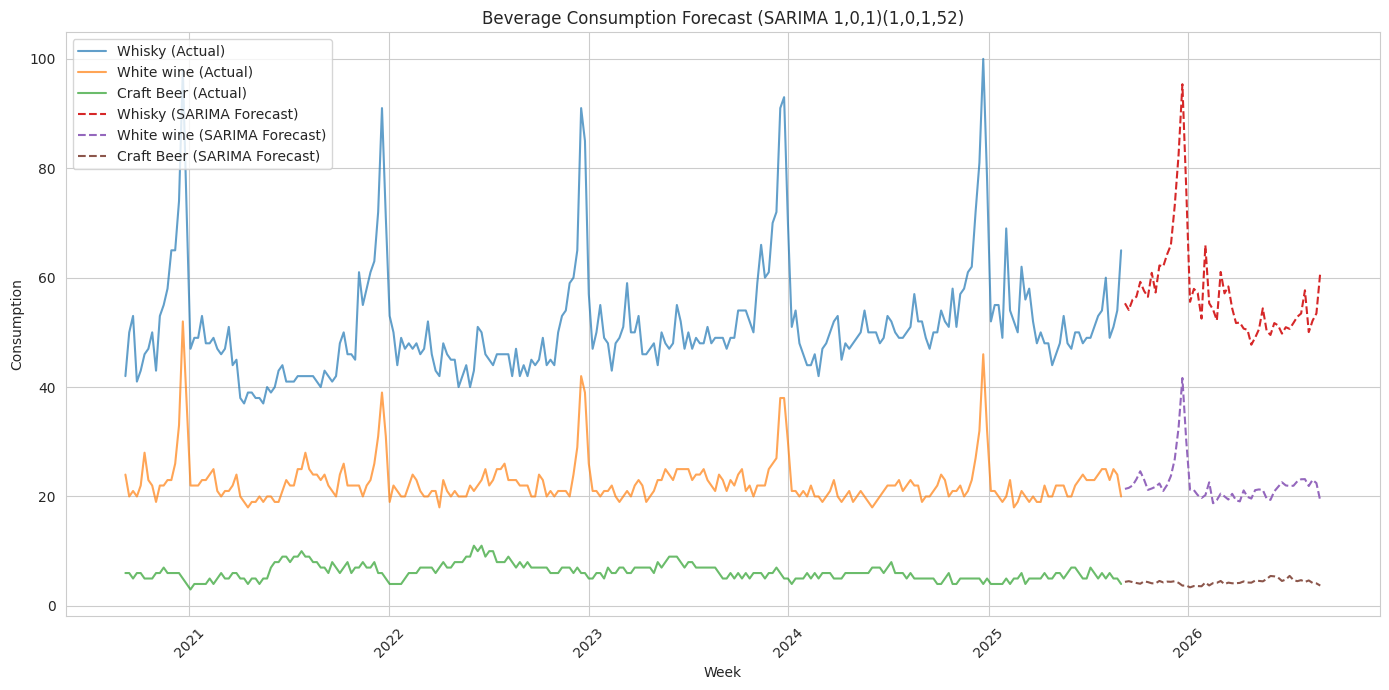

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define the SARIMA order and seasonal order
order = (1, 0, 1)
seasonal_order = (1, 0, 1, 52) # (P, D, Q, S)

# Fit SARIMA model for Whisky
model_whisky_sarima = SARIMAX(data_cleaned['Whisky'].dropna(), order=order, seasonal_order=seasonal_order)
results_whisky_sarima = model_whisky_sarima.fit()
print("--- SARIMA (1,0,1)(1,0,1,52) Results for Whisky ---")
print(results_whisky_sarima.summary())

# Fit SARIMA model for White wine
model_white_wine_sarima = SARIMAX(data_cleaned['White wine'].dropna(), order=order, seasonal_order=seasonal_order)
results_white_wine_sarima = model_white_wine_sarima.fit()
print("\n--- SARIMA (1,0,1)(1,0,1,52) Results for White wine ---")
print(results_white_wine_sarima.summary())

# Fit SARIMA model for Craft Beer
model_craft_beer_sarima = SARIMAX(data_cleaned['Craft Beer'].dropna(), order=order, seasonal_order=seasonal_order)
results_craft_beer_sarima = model_craft_beer_sarima.fit()
print("\n--- SARIMA (1,0,1)(1,0,1,52) Results for Craft Beer ---")
print(results_craft_beer_sarima.summary())

# Forecast the next 52 weeks (1 year)
forecast_steps = 52

forecast_whisky_sarima = results_whisky_sarima.forecast(steps=forecast_steps)
forecast_white_wine_sarima = results_white_wine_sarima.forecast(steps=forecast_steps)
forecast_craft_beer_sarima = results_craft_beer_sarima.forecast(steps=forecast_steps)

# Create a date index for the forecast
last_date = data_cleaned['Week'].iloc[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=forecast_steps, freq='W')

# Plot the actual and forecasted values
plt.figure(figsize=(14, 7))

plt.plot(data_cleaned['Week'], data_cleaned['Whisky'], label='Whisky (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['White wine'], label='White wine (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer'], label='Craft Beer (Actual)', alpha=0.7)

plt.plot(forecast_dates, forecast_whisky_sarima, label='Whisky (SARIMA Forecast)', linestyle='--')
plt.plot(forecast_dates, forecast_white_wine_sarima, label='White wine (SARIMA Forecast)', linestyle='--')
plt.plot(forecast_dates, forecast_craft_beer_sarima, label='Craft Beer (SARIMA Forecast)', linestyle='--')

plt.title('Beverage Consumption Forecast (SARIMA 1,0,1)(1,0,1,52)')
plt.xlabel('Week')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


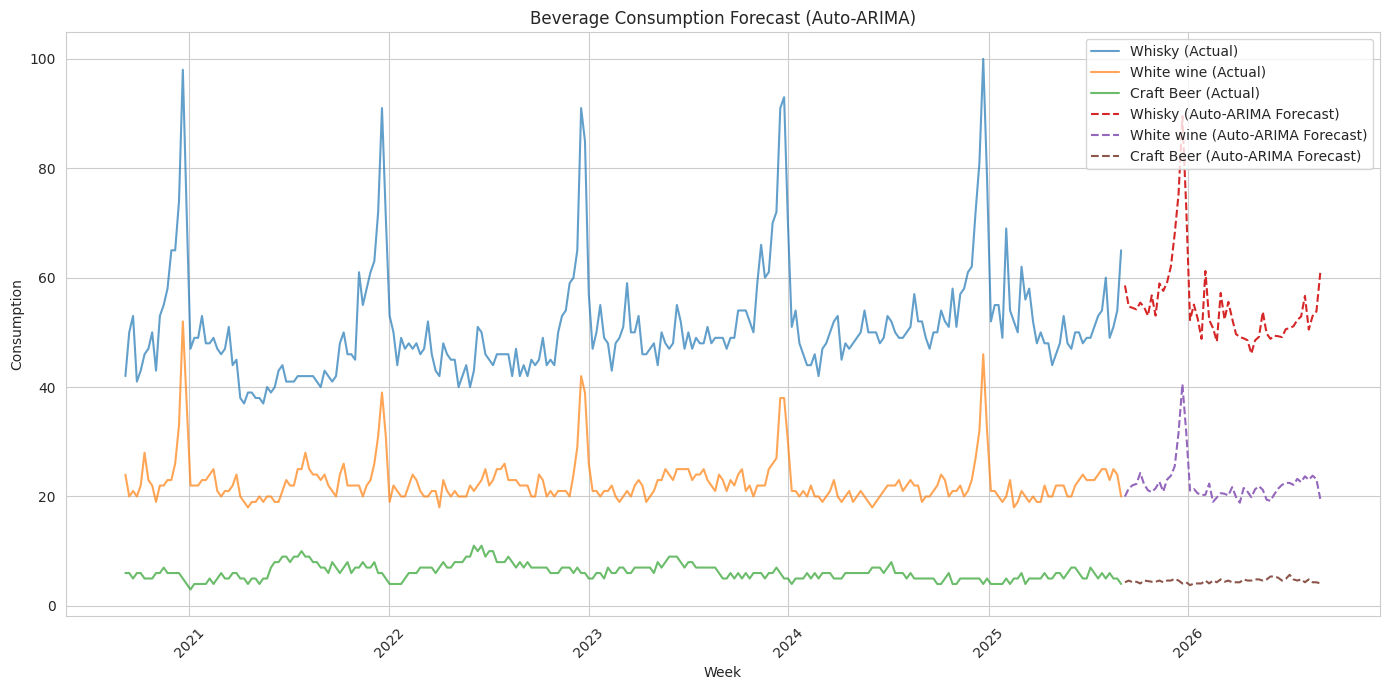

In [7]:
# Extract the best models from Auto-ARIMA results
# best_model_whisky = auto_arima_whisky.model_ # This line is incorrect
# best_model_white_wine = auto_arima_white_wine.model_ # This line is incorrect
# best_model_craft_beer = auto_arima_craft_beer.model_ # This line is incorrect

# Forecast the next 52 weeks (1 year) using the best models
forecast_steps = 52

forecast_whisky_auto = auto_arima_whisky.predict(n_periods=forecast_steps)
forecast_white_wine_auto = auto_arima_white_wine.predict(n_periods=forecast_steps)
forecast_craft_beer_auto = auto_arima_craft_beer.predict(n_periods=forecast_steps)

# Create a date index for the forecast
last_date = data_cleaned['Week'].iloc[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=forecast_steps, freq='W')

# Plot the actual and forecasted values
plt.figure(figsize=(14, 7))

plt.plot(data_cleaned['Week'], data_cleaned['Whisky'], label='Whisky (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['White wine'], label='White wine (Actual)', alpha=0.7)
plt.plot(data_cleaned['Week'], data_cleaned['Craft Beer'], label='Craft Beer (Actual)', alpha=0.7)

plt.plot(forecast_dates, forecast_whisky_auto, label='Whisky (Auto-ARIMA Forecast)', linestyle='--')
plt.plot(forecast_dates, forecast_white_wine_auto, label='White wine (Auto-ARIMA Forecast)', linestyle='--')
plt.plot(forecast_dates, forecast_craft_beer_auto, label='Craft Beer (Auto-ARIMA Forecast)', linestyle='--')

plt.title('Beverage Consumption Forecast (Auto-ARIMA)')
plt.xlabel('Week')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()